In [1]:
import pandas as pd
import numpy as np

# 读数据
players = pd.read_parquet("E:/players.parquet")
games = pd.read_parquet("E:/games.parquet")
events = pd.read_parquet("E:/events.parquet")

# 看基本形状
print("players shape:", players.shape)
print("games shape:", games.shape)
print("events shape:", events.shape)

# 看列名
print("\nplayers columns:")
print(players.columns.tolist())

print("\ngames columns:")
print(games.columns.tolist())

print("\nevents columns:")
print(events.columns.tolist())

players shape: (11472, 7)
games shape: (1435, 6)
events shape: (407262, 17)

players columns:
['game_id', 'player_id', 'role', 'model_name', 'alive_end', 'eliminated_during_day', 'eliminated_during_phase']

games columns:
['game_id', 'filename', 'winner_team', 'last_day', 'n_players', 'end_reason']

events columns:
['game_id', 'filename', 'outer_idx', 'inner_idx', 'data_type', 'event_name', 'day', 'phase', 'detailed_phase', 'source', 'public', 'visible_in_ui', 'created_at', 'actor_id', 'target_id', 'reasoning', 'description']


In [2]:
# 查看有哪些角色
role_counts_raw = players["role"].value_counts(dropna=False)
print(role_counts_raw)

# 转成表格
role_counts = role_counts_raw.reset_index()
role_counts.columns = ["role", "count"]

role_counts

role
Villager    5736
Werewolf    2868
Seer        1434
Doctor      1434
Name: count, dtype: int64


,role,count
0,Villager,5736
1,Werewolf,2868
2,Seer,1434
3,Doctor,1434


In [3]:
# 检查 alive_end 的取值
print(players["alive_end"].value_counts(dropna=False))

# 计算每个角色的生存率
role_survival = (
    players.groupby("role")
    .agg(
        n_players=("player_id", "count"),
        n_survived=("alive_end", "sum"),
        survive_rate=("alive_end", "mean")
    )
    .reset_index()
    .sort_values("survive_rate", ascending=False)
)

role_survival

alive_end
False    6288
True     5184
Name: count, dtype: int64


,role,n_players,n_survived,survive_rate
2,Villager,5736,3146,0.548466
0,Doctor,1434,738,0.514644
1,Seer,1434,559,0.389819
3,Werewolf,2868,741,0.258368


In [4]:
print(players["eliminated_during_day"].value_counts(dropna=False))
print(players["eliminated_during_phase"].value_counts(dropna=False))

eliminated_during_day
-1    5184
 1    2432
 2    2009
 0    1188
 3     638
 4      21
Name: count, dtype: int64
eliminated_during_phase
None     5184
Day      3424
Night    2864
Name: count, dtype: int64


In [6]:
role_elimination = (
    players.groupby("role")
    .agg(
        n_players=("player_id", "count"),
        day_elim_rate=("eliminated_during_phase", lambda x: (x == "Day").mean()),
        night_elim_rate=("eliminated_during_phase", lambda x: (x == "Night").mean()),
        survive_rate=("eliminated_during_phase", lambda x: (x.isna()).mean())
    )
    .reset_index()
)

role_elimination

,role,n_players,day_elim_rate,night_elim_rate,survive_rate
0,Doctor,1434,0.142259,0.343096,0.514644
1,Seer,1434,0.131102,0.479079,0.389819
2,Villager,5736,0.157775,0.293759,0.548466
3,Werewolf,2868,0.741632,0.000000,0.258368


In [7]:
role_summary = (
    role_counts
    .merge(role_survival, on="role", how="left")
    .merge(role_elimination, on=["role", "n_players"], how="left")
)

role_summary

,role,count,n_players,n_survived,survive_rate_x,day_elim_rate,night_elim_rate,survive_rate_y
0,Villager,5736,5736,3146,0.548466,0.157775,0.293759,0.548466
1,Werewolf,2868,2868,741,0.258368,0.741632,0.000000,0.258368
2,Seer,1434,1434,559,0.389819,0.131102,0.479079,0.389819
3,Doctor,1434,1434,738,0.514644,0.142259,0.343096,0.514644


In [9]:
role_summary.to_csv("E:/role_summary.csv", index=False)

In [10]:
events.head()

,game_id,filename,outer_idx,inner_idx,data_type,event_name,day,phase,detailed_phase,source,public,visible_in_ui,created_at,actor_id,target_id,reasoning,description
0,74788902,74788902.json,0,0,GameStartDataEntry,moderator_announcement,0,Night,NIGHT_START,MODERATOR,True,True,2026-03-19 16:12:44.673907+00:00,None,None,None,Werewolf game begins.\n - **Player Roster:** [...
1,74788902,74788902.json,0,1,GameStartRoleDataEntry,game_start,0,Night,NIGHT_START,MODERATOR,False,True,2026-03-19 16:12:44.674039+00:00,Jordan,None,None,"Your player id is ""Jordan"". Your team is ""Were..."
2,74788902,74788902.json,0,2,GameStartRoleDataEntry,game_start,0,Night,NIGHT_START,MODERATOR,False,True,2026-03-19 16:12:44.674088+00:00,Jamie,None,None,"Your player id is ""Jamie"". Your team is ""Villa..."
3,74788902,74788902.json,0,3,GameStartRoleDataEntry,game_start,0,Night,NIGHT_START,MODERATOR,False,True,2026-03-19 16:12:44.674140+00:00,Alex,None,None,"Your player id is ""Alex"". Your team is ""Villag..."
4,74788902,74788902.json,0,4,GameStartRoleDataEntry,game_start,0,Night,NIGHT_START,MODERATOR,False,True,2026-03-19 16:12:44.674182+00:00,Casey,None,None,"Your player id is ""Casey"". Your team is ""Villa..."


In [11]:
events["event_name"].value_counts()

event_name
phase_change                 103287
discussion                    81020
vote_action                   46421
chat_request                  40594
phase_divider                 35238
vote_request                  29785
game_start                    11480
moderator_announcement         9115
vote_order                     7078
elimination                    6289
eliminate_proposal_action      5872
vote_result                    3652
night_start                    3614
day_start                      3464
discussion_order               3464
heal_request                   2983
heal_action                    2980
inspect_request                2872
inspect_result                 2861
inspect_action                 2861
game_end                       1434
heal_result                     746
no_op_action                    144
error                             8
Name: count, dtype: int64

In [28]:
print(players["role"].value_counts(dropna=False))
print(games["winner_team"].value_counts(dropna=False))
print(players2["team"].value_counts(dropna=False))

role
Villager    5736
Werewolf    2868
Seer        1434
Doctor      1434
Name: count, dtype: int64
winner_team
Villagers     1000
Werewolves     434
None             1
Name: count, dtype: int64
team
villagers     8604
werewolves    2868
Name: count, dtype: int64


In [29]:
import pandas as pd
import numpy as np

players2 = players.merge(
    games[["game_id", "winner_team"]],
    on="game_id",
    how="left"
).copy()

# 标准化阵营
players2["team"] = players2["role"].apply(
    lambda x: "werewolves" if str(x).lower() == "werewolf" else "villagers"
)

players2["winner_team_std"] = players2["winner_team"].astype(str).str.lower().str.strip()

players2["win"] = (players2["team"] == players2["winner_team_std"]).astype(int)

In [30]:
seer_features = (
    events[events["event_name"] == "inspect_action"]
    .groupby(["game_id", "actor_id"])
    .size()
    .reset_index(name="n_inspects")
)

# merge
players2 = players2.merge(
    seer_features,
    left_on=["game_id", "player_id"],
    right_on=["game_id", "actor_id"],
    how="left"
)

players2["n_inspects"] = players2["n_inspects"].fillna(0)
doctor_features = (
    events[events["event_name"] == "heal_action"]
    .groupby(["game_id", "actor_id"])
    .size()
    .reset_index(name="n_heals")
)

players2 = players2.merge(
    doctor_features,
    left_on=["game_id", "player_id"],
    right_on=["game_id", "actor_id"],
    how="left"
)

players2["n_heals"] = players2["n_heals"].fillna(0)
wolf_features = (
    events[
        (events["event_name"] == "vote_action") &
        (events["phase"] == "Night")
    ]
    .groupby(["game_id", "actor_id"])
    .size()
    .reset_index(name="n_wolf_votes")
)

players2 = players2.merge(
    wolf_features,
    left_on=["game_id", "player_id"],
    right_on=["game_id", "actor_id"],
    how="left"
)

players2["n_wolf_votes"] = players2["n_wolf_votes"].fillna(0)

In [31]:
seer_analysis = (
    players2[players2["role"] == "Seer"]
    .groupby("win")
    .agg(
        avg_inspects=("n_inspects", "mean"),
        median_inspects=("n_inspects", "median"),
        count=("player_id", "count")
    )
    .reset_index()
)

seer_analysis

,win,avg_inspects,median_inspects,count
0,0,1.723502,2.0,434
1,1,2.112000,2.0,1000


In [32]:
doctor_analysis = (
    players2[players2["role"] == "Doctor"]
    .groupby("win")
    .agg(
        avg_heals=("n_heals", "mean"),
        median_heals=("n_heals", "median"),
        count=("player_id", "count")
    )
    .reset_index()
)

doctor_analysis

,win,avg_heals,median_heals,count
0,0,2.096774,2.0,434
1,1,2.068000,2.0,1000


In [33]:
wolf_analysis = (
    players2[players2["team"] == "werewolves"]
    .groupby("win")
    .agg(
        avg_votes=("n_wolf_votes", "mean"),
        median_votes=("n_wolf_votes", "median"),
        count=("player_id", "count")
    )
    .reset_index()
)

wolf_analysis

,win,avg_votes,median_votes,count
0,0,1.904000,2.0,2000
1,1,2.375576,2.0,868


In [34]:
players2["seer_bin"] = pd.cut(
    players2["n_inspects"],
    bins=[-1, 0, 2, 5, 10],
    labels=["0", "1-2", "3-5", "6+"]
)

seer_bin_analysis = (
    players2[players2["role"] == "Seer"]
    .groupby("seer_bin")
    .agg(win_rate=("win", "mean"))
    .reset_index()
)

seer_bin_analysis

C:\Users\宋润琳\AppData\Local\Temp\ipykernel_27272\2566363702.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("seer_bin")


,seer_bin,win_rate
0,0,NaN
1,1-2,0.676147
2,3-5,0.764535
3,6+,NaN


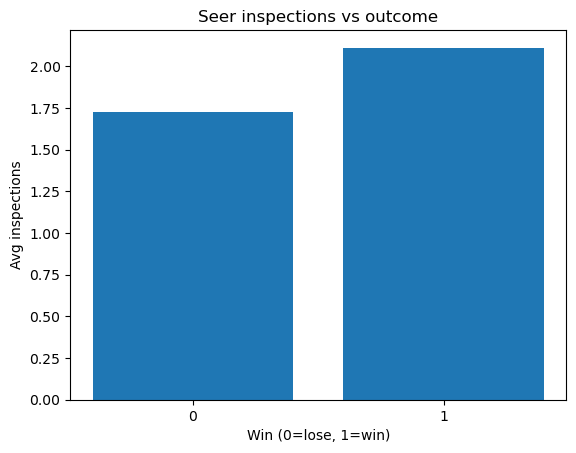

In [35]:
import matplotlib.pyplot as plt

plt.bar(seer_analysis["win"].astype(str), seer_analysis["avg_inspects"])
plt.xlabel("Win (0=lose, 1=win)")
plt.ylabel("Avg inspections")
plt.title("Seer inspections vs outcome")
plt.show()

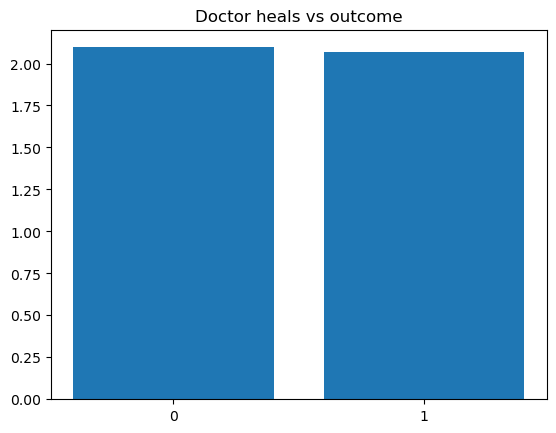

In [36]:
plt.bar(doctor_analysis["win"].astype(str), doctor_analysis["avg_heals"])
plt.title("Doctor heals vs outcome")
plt.show()

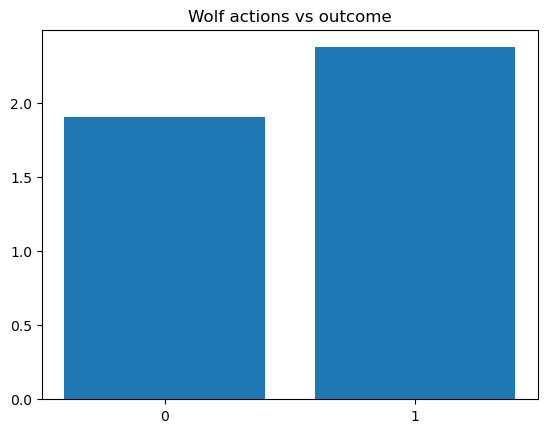

In [37]:
plt.bar(wolf_analysis["win"].astype(str), wolf_analysis["avg_votes"])
plt.title("Wolf actions vs outcome")
plt.show()

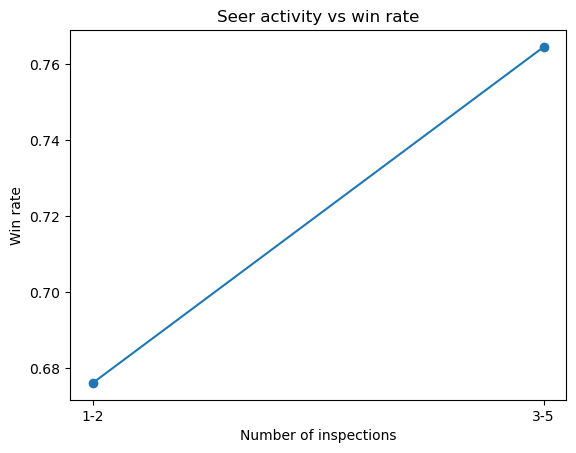

In [38]:
plt.plot(
    seer_bin_analysis["seer_bin"].astype(str),
    seer_bin_analysis["win_rate"],
    marker="o"
)

plt.xlabel("Number of inspections")
plt.ylabel("Win rate")
plt.title("Seer activity vs win rate")
plt.show()

In [39]:
heal_events = events[events["event_name"] == "heal_action"].copy()

heal_events.head()

,game_id,filename,outer_idx,inner_idx,data_type,event_name,day,phase,detailed_phase,source,public,visible_in_ui,created_at,actor_id,target_id,reasoning,description
19,74788902,74788902.json,1,2,DoctorHealActionDataEntry,heal_action,0,Night,NIGHT_AWAIT_ACTIONS,MODERATOR,False,True,2026-03-19 16:13:03.996413+00:00,Charlie,Alex,Night 0 - no information yet. I need to protec...,"Player Charlie, you chose to heal player Alex."
147,74788902,74788902.json,25,2,DoctorHealActionDataEntry,heal_action,1,Night,NIGHT_AWAIT_ACTIONS,MODERATOR,False,True,2026-03-19 16:19:11.908043+00:00,Charlie,Kai,"Quinn flipped Werewolf, confirming Alex as the...","Player Charlie, you chose to heal player Kai."
258,74788904,74788904.json,1,2,DoctorHealActionDataEntry,heal_action,0,Night,NIGHT_AWAIT_ACTIONS,MODERATOR,False,True,2026-03-19 16:12:46.891124+00:00,Casey,Alex,Night 0 - no information yet. I need to protec...,"Player Casey, you chose to heal player Alex."
386,74788904,74788904.json,25,2,DoctorHealActionDataEntry,heal_action,1,Night,NIGHT_AWAIT_ACTIONS,MODERATOR,False,True,2026-03-19 16:18:07.018405+00:00,Casey,Quinn,"We just mis-exiled Jamie, who was a Villager. ...","Player Casey, you chose to heal player Quinn."
501,74788934,74788934.json,1,2,DoctorHealActionDataEntry,heal_action,0,Night,NIGHT_AWAIT_ACTIONS,MODERATOR,False,True,2026-03-19 16:18:01.259599+00:00,Charlie,Alex,"Night 0 gives no behavioral information, so al...","Player Charlie, you chose to heal player Alex."


In [41]:
wolf_kill = events[
    (events["event_name"] == "vote_action") &
    (events["phase"] == "Night")
].copy()
wolf_target = (
    wolf_kill.groupby(["game_id", "day", "target_id"])
    .size()
    .reset_index(name="n_votes")
)

wolf_target.head()

,game_id,day,target_id,n_votes
0,74788902,0,Taylor,2
1,74788902,1,Alex,1
2,74788904,0,Charlie,2
3,74788904,1,Casey,2
4,74788934,0,Alex,2


In [42]:
wolf_final_target = (
    wolf_target.sort_values(["game_id", "day", "n_votes"], ascending=[True, True, False])
    .drop_duplicates(["game_id", "day"])
    .rename(columns={"target_id": "wolf_target"})
)

wolf_final_target.head()

,game_id,day,wolf_target,n_votes
0,74788902,0,Taylor,2
1,74788902,1,Alex,1
2,74788904,0,Charlie,2
3,74788904,1,Casey,2
4,74788934,0,Alex,2


In [44]:
heal_check = heal_events.merge(
    wolf_final_target[["game_id", "day", "wolf_target"]],
    on=["game_id", "day"],
    how="left"
)
heal_check["heal_success"] = (
    heal_check["target_id"] == heal_check["wolf_target"]
).astype(int)

heal_check.head()

,game_id,filename,outer_idx,inner_idx,data_type,event_name,day,phase,detailed_phase,source,public,visible_in_ui,created_at,actor_id,target_id,reasoning,description,wolf_target,heal_success
0,74788902,74788902.json,1,2,DoctorHealActionDataEntry,heal_action,0,Night,NIGHT_AWAIT_ACTIONS,MODERATOR,False,True,2026-03-19 16:13:03.996413+00:00,Charlie,Alex,Night 0 - no information yet. I need to protec...,"Player Charlie, you chose to heal player Alex.",Taylor,0
1,74788902,74788902.json,25,2,DoctorHealActionDataEntry,heal_action,1,Night,NIGHT_AWAIT_ACTIONS,MODERATOR,False,True,2026-03-19 16:19:11.908043+00:00,Charlie,Kai,"Quinn flipped Werewolf, confirming Alex as the...","Player Charlie, you chose to heal player Kai.",Alex,0
2,74788904,74788904.json,1,2,DoctorHealActionDataEntry,heal_action,0,Night,NIGHT_AWAIT_ACTIONS,MODERATOR,False,True,2026-03-19 16:12:46.891124+00:00,Casey,Alex,Night 0 - no information yet. I need to protec...,"Player Casey, you chose to heal player Alex.",Charlie,0
3,74788904,74788904.json,25,2,DoctorHealActionDataEntry,heal_action,1,Night,NIGHT_AWAIT_ACTIONS,MODERATOR,False,True,2026-03-19 16:18:07.018405+00:00,Casey,Quinn,"We just mis-exiled Jamie, who was a Villager. ...","Player Casey, you chose to heal player Quinn.",Casey,0
4,74788934,74788934.json,1,2,DoctorHealActionDataEntry,heal_action,0,Night,NIGHT_AWAIT_ACTIONS,MODERATOR,False,True,2026-03-19 16:18:01.259599+00:00,Charlie,Alex,"Night 0 gives no behavioral information, so al...","Player Charlie, you chose to heal player Alex.",Alex,1


In [45]:
doctor_success = (
    heal_check.groupby(["game_id", "actor_id"])
    .agg(
        n_heals=("heal_success", "count"),
        n_success=("heal_success", "sum")
    )
    .reset_index()
)

doctor_success["success_rate"] = doctor_success["n_success"] / doctor_success["n_heals"]

doctor_success.head()

,game_id,actor_id,n_heals,n_success,success_rate
0,74788902,Charlie,2,0,0.000000
1,74788904,Casey,2,0,0.000000
2,74788934,Charlie,3,1,0.333333
3,74788967,Kai,3,1,0.333333
4,74788999,Quinn,2,0,0.000000


In [46]:
doctor_success = doctor_success.merge(
    players2[["game_id", "player_id", "win", "role"]],
    left_on=["game_id", "actor_id"],
    right_on=["game_id", "player_id"],
    how="left"
)

doctor_success = doctor_success[doctor_success["role"] == "Doctor"]
doctor_quality_analysis = (
    doctor_success.groupby("win")
    .agg(
        avg_success_rate=("success_rate", "mean"),
        avg_success_count=("n_success", "mean"),
        count=("actor_id", "count")
    )
    .reset_index()
)

doctor_quality_analysis

,win,avg_success_rate,avg_success_count,count
0,0.0,0.145929,0.364055,434
1,1.0,0.254417,0.588000,1000


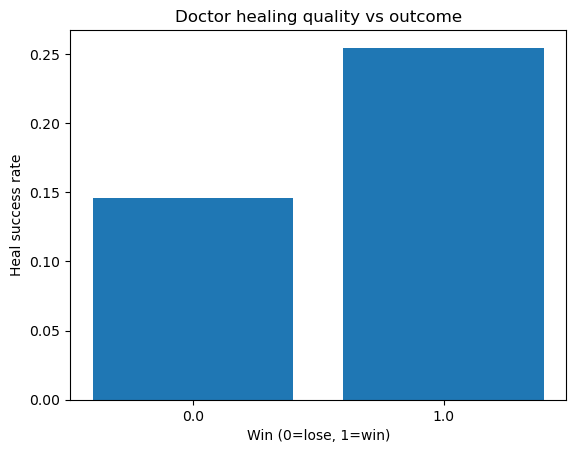

In [47]:
import matplotlib.pyplot as plt

plt.bar(
    doctor_quality_analysis["win"].astype(str),
    doctor_quality_analysis["avg_success_rate"]
)

plt.xlabel("Win (0=lose, 1=win)")
plt.ylabel("Heal success rate")
plt.title("Doctor healing quality vs outcome")
plt.show()

In [48]:
seer_result = events[events["event_name"] == "inspect_result"].copy()

seer_result.head()

,game_id,filename,outer_idx,inner_idx,data_type,event_name,day,phase,detailed_phase,source,public,visible_in_ui,created_at,actor_id,target_id,reasoning,description
18,74788902,74788902.json,1,1,SeerInspectResultDataEntry,inspect_result,0,Night,NIGHT_AWAIT_ACTIONS,MODERATOR,False,True,2026-03-19 16:13:03.995962+00:00,Alex,Quinn,None,"Player ""Alex"", you inspected Quinn. Their role..."
146,74788902,74788902.json,25,1,SeerInspectResultDataEntry,inspect_result,1,Night,NIGHT_AWAIT_ACTIONS,MODERATOR,False,True,2026-03-19 16:19:11.907964+00:00,Alex,Jordan,None,"Player ""Alex"", you inspected Jordan. Their rol..."
257,74788904,74788904.json,1,1,SeerInspectResultDataEntry,inspect_result,0,Night,NIGHT_AWAIT_ACTIONS,MODERATOR,False,True,2026-03-19 16:12:46.890882+00:00,Jordan,Quinn,None,"Player ""Jordan"", you inspected Quinn. Their ro..."
385,74788904,74788904.json,25,1,SeerInspectResultDataEntry,inspect_result,1,Night,NIGHT_AWAIT_ACTIONS,MODERATOR,False,True,2026-03-19 16:18:07.018347+00:00,Jordan,Alex,None,"Player ""Jordan"", you inspected Alex. Their rol..."
500,74788934,74788934.json,1,1,SeerInspectResultDataEntry,inspect_result,0,Night,NIGHT_AWAIT_ACTIONS,MODERATOR,False,True,2026-03-19 16:18:01.259355+00:00,Alex,Taylor,None,"Player ""Alex"", you inspected Taylor. Their rol..."


In [55]:
seer_result = events[
    events["event_name"] == "inspect_result"
].copy()
seer_result["found_wolf"] = seer_result["visible_in_ui"].astype(int)
seer_result["found_wolf"].value_counts()

found_wolf
1    2861
Name: count, dtype: int64

In [59]:
seer_result = events[events["event_name"] == "inspect_result"].copy()
seer_result = seer_result.merge(
    players[["game_id", "player_id", "role"]],
    left_on=["game_id", "target_id"],
    right_on=["game_id", "player_id"],
    how="left"
)
seer_result["found_wolf"] = (
    seer_result["role"].astype(str).str.lower() == "werewolf"
).astype(int)
seer_result["found_wolf"].value_counts(dropna=False)
seer_result[["game_id", "actor_id", "target_id", "role", "found_wolf"]].head(20)

,game_id,actor_id,target_id,role,found_wolf
0,74788902,Alex,Quinn,Werewolf,1
1,74788902,Alex,Jordan,Werewolf,1
2,74788904,Jordan,Quinn,Villager,0
3,74788904,Jordan,Alex,Werewolf,1
4,74788934,Alex,Taylor,Werewolf,1
5,74788967,Jamie,Taylor,Villager,0
6,74788999,Jamie,Alex,Villager,0
7,74789000,Alex,Jordan,Werewolf,1
8,74789000,Alex,Casey,Villager,0
9,74789096,Jordan,Taylor,Doctor,0


In [60]:
seer_quality = (
    seer_result.groupby(["game_id", "actor_id"])
    .agg(
        n_inspects=("found_wolf", "count"),
        n_found=("found_wolf", "sum")
    )
    .reset_index()
)

seer_quality["success_rate"] = (
    seer_quality["n_found"] / seer_quality["n_inspects"]
)
seer_quality = seer_quality.merge(
    players2[["game_id", "player_id", "win", "role"]],
    left_on=["game_id", "actor_id"],
    right_on=["game_id", "player_id"],
    how="left"
)

seer_quality = seer_quality[seer_quality["role"] == "Seer"]
seer_quality_analysis = (
    seer_quality.groupby("win")
    .agg(
        avg_success_rate=("success_rate", "mean"),
        avg_found=("n_found", "mean"),
        count=("actor_id", "count")
    )
    .reset_index()
)

seer_quality_analysis

,win,avg_success_rate,avg_found,count
0,0.0,0.324693,0.559908,434
1,1.0,0.555167,1.160000,1000


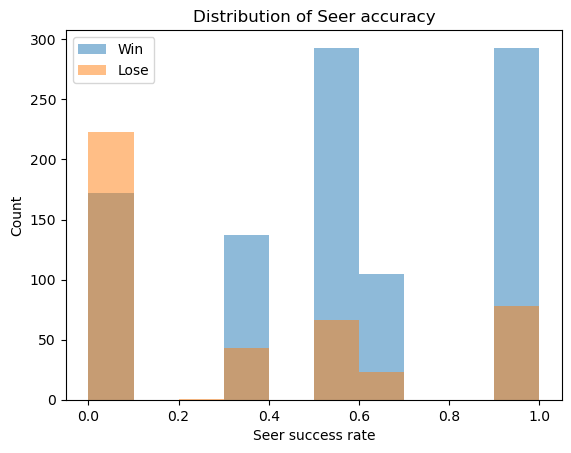

In [61]:
plt.hist(
    seer_quality[seer_quality["win"] == 1]["success_rate"],
    alpha=0.5,
    label="Win"
)

plt.hist(
    seer_quality[seer_quality["win"] == 0]["success_rate"],
    alpha=0.5,
    label="Lose"
)

plt.xlabel("Seer success rate")
plt.ylabel("Count")
plt.title("Distribution of Seer accuracy")
plt.legend()
plt.show()

In [64]:
day_votes = events[
    (events["event_name"] == "vote_action") &
    (events["phase"] == "Day")
].copy()

print(day_votes.shape)
day_votes[["game_id", "day", "actor_id", "target_id", "phase"]].head()

(40548, 17)


,game_id,day,actor_id,target_id,phase
106,74788902,1,Jordan,Alex,Day
107,74788902,1,Jordan,Alex,Day
110,74788902,1,Jamie,Quinn,Day
111,74788902,1,Jamie,Quinn,Day
114,74788902,1,Alex,Quinn,Day


In [65]:
day_votes = day_votes.merge(
    players[["game_id", "player_id", "role"]],
    left_on=["game_id", "actor_id"],
    right_on=["game_id", "player_id"],
    how="left"
)

print(day_votes["role"].value_counts(dropna=False))

role
Villager    20026
Werewolf    11252
Doctor       4874
Seer         4334
NaN            62
Name: count, dtype: int64


In [66]:
wolf_votes_day = day_votes[day_votes["role"] == "Werewolf"].copy()

print(wolf_votes_day.shape)
wolf_votes_day[["game_id", "day", "actor_id", "target_id", "role"]].head(10)

(11252, 19)


,game_id,day,actor_id,target_id,role
0,74788902,1,Jordan,Alex,Werewolf
1,74788902,1,Jordan,Alex,Werewolf
8,74788902,1,Quinn,Alex,Werewolf
9,74788902,1,Quinn,Alex,Werewolf
22,74788902,2,Jordan,Kai,Werewolf
23,74788902,2,Jordan,Kai,Werewolf
34,74788904,1,Alex,Jamie,Werewolf
35,74788904,1,Alex,Jamie,Werewolf
36,74788904,1,Kai,Jamie,Werewolf
37,74788904,1,Kai,Jamie,Werewolf


In [67]:
wolf_day_consistency = (
    wolf_votes_day.groupby(["game_id", "day"])
    .agg(
        n_wolves=("actor_id", "nunique"),
        n_targets=("target_id", "nunique")
    )
    .reset_index()
)

wolf_day_consistency["consistent"] = (
    wolf_day_consistency["n_targets"] == 1
).astype(int)

wolf_day_consistency.head(20)

,game_id,day,n_wolves,n_targets,consistent
0,74788902,1,2,1,1
1,74788902,2,1,1,1
2,74788904,1,2,1,1
3,74788904,2,2,1,1
4,74788934,1,2,1,1
5,74788934,2,2,2,0
6,74788934,3,1,1,1
7,74788967,1,2,1,1
8,74788967,2,2,1,1
9,74788999,1,2,1,1


In [68]:
wolf_game = (
    wolf_day_consistency.groupby("game_id")
    .agg(
        consistency_rate=("consistent", "mean"),
        n_days=("day", "count")
    )
    .reset_index()
)

wolf_game.head()

,game_id,consistency_rate,n_days
0,74788902,1.000000,2
1,74788904,1.000000,2
2,74788934,0.666667,3
3,74788967,1.000000,2
4,74788999,1.000000,2


In [69]:
wolf_game = wolf_game.merge(
    games[["game_id", "winner_team"]],
    on="game_id",
    how="left"
)

wolf_game["wolf_win"] = (
    wolf_game["winner_team"] == "Werewolves"
).astype(int)

wolf_game.head()

,game_id,consistency_rate,n_days,winner_team,wolf_win
0,74788902,1.000000,2,Villagers,0
1,74788904,1.000000,2,Werewolves,1
2,74788934,0.666667,3,Werewolves,1
3,74788967,1.000000,2,Werewolves,1
4,74788999,1.000000,2,Werewolves,1


In [70]:
wolf_analysis = (
    wolf_game.groupby("wolf_win")
    .agg(
        avg_consistency=("consistency_rate", "mean"),
        avg_days=("n_days", "mean"),
        count=("game_id", "count")
    )
    .reset_index()
)

wolf_analysis

,wolf_win,avg_consistency,avg_days,count
0,0,0.661917,2.451000,1000
1,1,0.865207,2.331797,434


In [71]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 输出目录
OUT_DIR = "role_figures"
os.makedirs(OUT_DIR, exist_ok=True)

# 全局风格
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11

def add_bar_labels(ax, fmt="{:.2f}", padding=0.01):
    ymin, ymax = ax.get_ylim()
    span = ymax - ymin
    for p in ax.patches:
        h = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2,
            h + span * padding,
            fmt.format(h),
            ha="center",
            va="bottom"
        )

def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, name), dpi=220, bbox_inches="tight")
    plt.show()

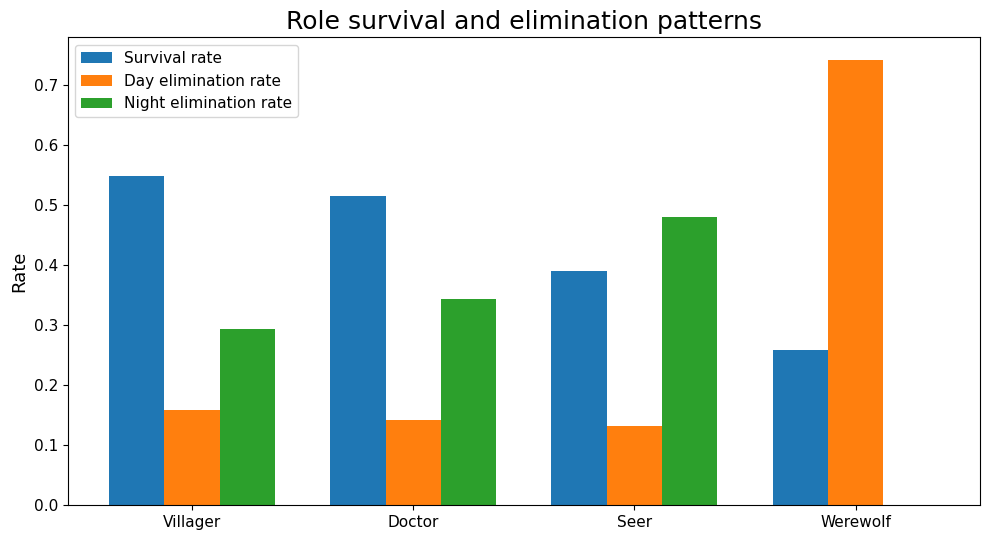

In [72]:
role_plot = role_summary.copy()

# 统一列名
if "survive_rate_x" in role_plot.columns:
    role_plot["survive_rate"] = role_plot["survive_rate_x"]
elif "survive_rate_y" in role_plot.columns:
    role_plot["survive_rate"] = role_plot["survive_rate_y"]

role_plot = role_plot[["role", "survive_rate", "day_elim_rate", "night_elim_rate"]].copy()
role_plot = role_plot.sort_values("survive_rate", ascending=False)

x = np.arange(len(role_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(x - width, role_plot["survive_rate"], width=width, label="Survival rate")
ax.bar(x, role_plot["day_elim_rate"], width=width, label="Day elimination rate")
ax.bar(x + width, role_plot["night_elim_rate"], width=width, label="Night elimination rate")

ax.set_xticks(x)
ax.set_xticklabels(role_plot["role"])
ax.set_ylabel("Rate")
ax.set_title("Role survival and elimination patterns")
ax.legend()

savefig("01_role_survival_elimination.png")

In [73]:
action_compare = pd.DataFrame({
    "role": ["Seer", "Seer", "Doctor", "Doctor", "Werewolf", "Werewolf"],
    "win": ["Lose", "Win", "Lose", "Win", "Lose", "Win"],
    "avg_actions": [
        seer_analysis.loc[seer_analysis["win"] == 0, "avg_inspects"].iloc[0],
        seer_analysis.loc[seer_analysis["win"] == 1, "avg_inspects"].iloc[0],
        doctor_analysis.loc[doctor_analysis["win"] == 0, "avg_heals"].iloc[0],
        doctor_analysis.loc[doctor_analysis["win"] == 1, "avg_heals"].iloc[0],
        wolf_analysis.loc[wolf_analysis["win"] == 0, "avg_votes"].iloc[0],
        wolf_analysis.loc[wolf_analysis["win"] == 1, "avg_votes"].iloc[0],
    ]
})

pivot_action = action_compare.pivot(index="role", columns="win", values="avg_actions")
pivot_action = pivot_action.loc[["Seer", "Doctor", "Werewolf"]]

x = np.arange(len(pivot_action))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(x - width/2, pivot_action["Lose"], width=width, label="Lose")
ax.bar(x + width/2, pivot_action["Win"], width=width, label="Win")

ax.set_xticks(x)
ax.set_xticklabels(pivot_action.index)
ax.set_ylabel("Average action count")
ax.set_title("Role action volume by game outcome")
ax.legend()

savefig("02_role_action_volume_by_outcome.png")

KeyError: 'win'

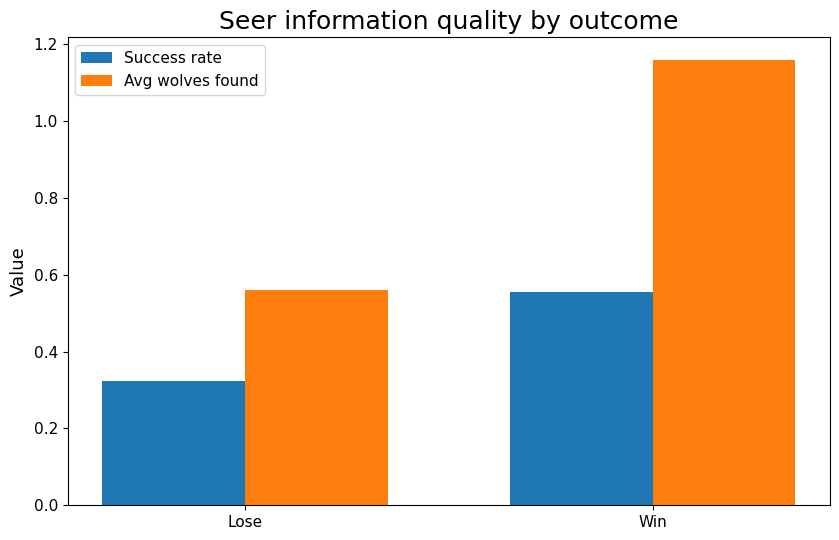

In [74]:
seer_quality_plot = seer_quality_analysis.copy()
seer_quality_plot["Outcome"] = seer_quality_plot["win"].map({0: "Lose", 1: "Win"})

x = np.arange(len(seer_quality_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.bar(x - width/2, seer_quality_plot["avg_success_rate"], width=width, label="Success rate")
ax.bar(x + width/2, seer_quality_plot["avg_found"], width=width, label="Avg wolves found")

ax.set_xticks(x)
ax.set_xticklabels(seer_quality_plot["Outcome"])
ax.set_ylabel("Value")
ax.set_title("Seer information quality by outcome")
ax.legend()

savefig("03_seer_quality_by_outcome.png")

In [85]:
# ✅ 统一配色（必须先运行）
ROLE_COLORS = {
    "Werewolf": "#7fb8b0",   # teal
    "Villager": "#e8cc7a",   # yellow
    "Seer": "#a9a7c7",       # purple
    "Doctor": "#e48375"      # coral
}

OUTCOME_COLORS = {
    "Win": "#e48375",   # coral
    "Lose": "#7fb8b0"   # teal
}

QUALITY_COLORS = {
    "rate": "#7fb8b0",
    "count": "#e8cc7a"
}

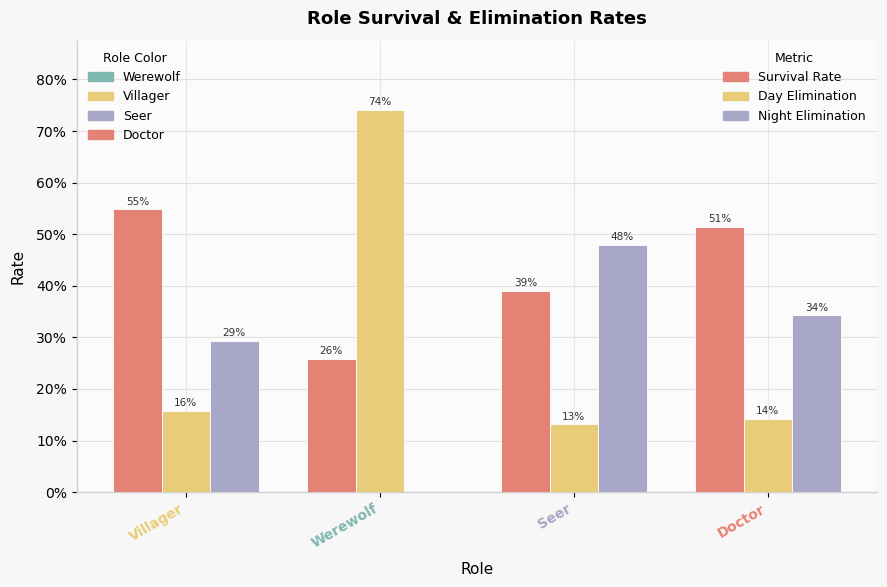

In [98]:
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(9, 6))

role_plot = role_summary.copy()
role_plot["survive_rate"] = role_plot["survive_rate_x"]

roles = role_plot["role"].tolist()
x = np.arange(len(roles))
w = 0.25

# 固定三组颜色（与 ROLE_COLORS / OUTCOME_COLORS 保持一致）
COLOR_SURVIVE  = "#e48375"  # coral  — 与 Seer/Doctor 同系，代表"存活"
COLOR_DAY_ELIM = "#e8cc7a"  # yellow — 与 Villager 同系，代表"白天淘汰"
COLOR_NIGHT_ELIM = "#a9a7c7"  # purple — 与 Seer 同系，代表"夜间淘汰"

# ── 绘制柱状图 ──────────────────────────────────────────────
bars1 = ax.bar(x - w, role_plot["survive_rate"],
               width=w, color=COLOR_SURVIVE,
               edgecolor="white", linewidth=0.6, zorder=3)

bars2 = ax.bar(x, role_plot["day_elim_rate"],
               width=w, color=COLOR_DAY_ELIM,
               edgecolor="white", linewidth=0.6, zorder=3)

bars3 = ax.bar(x + w, role_plot["night_elim_rate"],
               width=w, color=COLOR_NIGHT_ELIM,
               edgecolor="white", linewidth=0.6, zorder=3)

# ── 数值标签 ─────────────────────────────────────────────────
def add_labels(bars):
    for bar in bars:
        h = bar.get_height()
        if h > 0.01:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                    f"{h:.0%}", ha="center", va="bottom",
                    fontsize=7.5, color="#333333")

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

# ── X 轴：角色名 + 色块标记 ───────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(roles, rotation=30, ha="right", fontsize=10)

# 给每个 x 轴 label 加上对应角色颜色的小色块
for tick, role in zip(ax.get_xticklabels(), roles):
    tick.set_color(ROLE_COLORS.get(role, "#333333"))
    tick.set_fontweight("bold")

# ── Y 轴 ──────────────────────────────────────────────────────
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, role_plot[["survive_rate", "day_elim_rate", "night_elim_rate"]].max().max() * 1.18)
ax.set_xlabel("Role", fontsize=11, labelpad=8)
ax.set_ylabel("Rate", fontsize=11, labelpad=8)

# ── 图例（双层）─────────────────────────────────────────────
# 第一行：三种指标
legend1 = [
    mpatches.Patch(color=COLOR_SURVIVE,   label="Survival Rate"),
    mpatches.Patch(color=COLOR_DAY_ELIM,  label="Day Elimination"),
    mpatches.Patch(color=COLOR_NIGHT_ELIM, label="Night Elimination"),
]
# 第二行：四种角色颜色说明
legend2 = [
    mpatches.Patch(color=c, label=role)
    for role, c in ROLE_COLORS.items()
]

leg1 = ax.legend(handles=legend1, frameon=False, fontsize=9,
                 loc="upper right", title="Metric", title_fontsize=9)
ax.add_artist(leg1)  # 保留第一个图例
ax.legend(handles=legend2, frameon=False, fontsize=9,
          loc="upper left", title="Role Color", title_fontsize=9)

# ── 美化 ──────────────────────────────────────────────────────
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="#e0e0e0", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Role Survival & Elimination Rates", fontsize=13, fontweight="bold", pad=12)

plt.tight_layout()
plt.show()

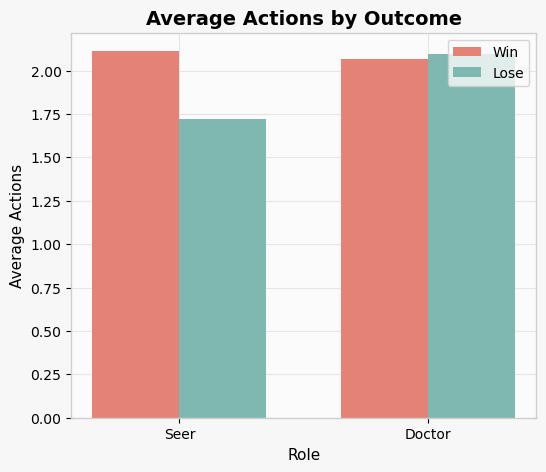

In [89]:
fig, ax = plt.subplots(figsize=(6,5))

roles = ["Seer", "Doctor"]

lose_vals = [
    seer_analysis.loc[seer_analysis["win"]==0, "avg_inspects"].iloc[0],
    doctor_analysis.loc[doctor_analysis["win"]==0, "avg_heals"].iloc[0]
]

win_vals = [
    seer_analysis.loc[seer_analysis["win"]==1, "avg_inspects"].iloc[0],
    doctor_analysis.loc[doctor_analysis["win"]==1, "avg_heals"].iloc[0]
]

x = np.arange(len(roles))
w = 0.35

ax.bar(x-w/2, win_vals,
       width=w,
       color=OUTCOME_COLORS["Win"],
       label="Win")

ax.bar(x+w/2, lose_vals,
       width=w,
       color=OUTCOME_COLORS["Lose"],
       label="Lose")

ax.set_xticks(x)
ax.set_xticklabels(roles)

ax.set_xlabel("Role")
ax.set_ylabel("Average Actions")
ax.legend()

ax.set_title("Average Actions by Outcome")

plt.show()

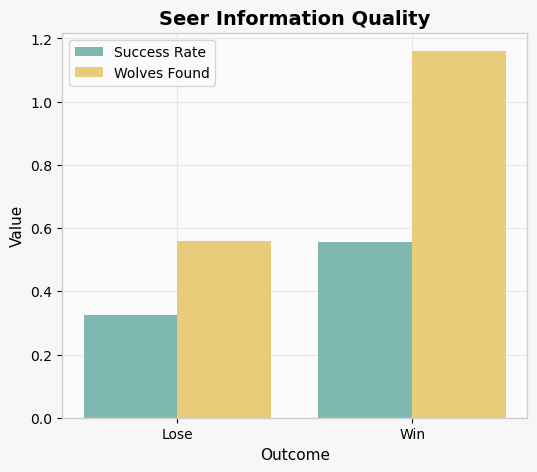

In [90]:
fig, ax = plt.subplots(figsize=(6,5))

x = np.arange(len(seer_quality_analysis))

ax.bar(x-0.2,
       seer_quality_analysis["avg_success_rate"],
       width=0.4,
       color=QUALITY_COLORS["rate"],
       label="Success Rate")

ax.bar(x+0.2,
       seer_quality_analysis["avg_found"],
       width=0.4,
       color=QUALITY_COLORS["count"],
       label="Wolves Found")

ax.set_xticks(x)
ax.set_xticklabels(["Lose","Win"])

ax.set_xlabel("Outcome")
ax.set_ylabel("Value")
ax.legend()

ax.set_title("Seer Information Quality")

plt.show()

C:\Users\宋润琳\AppData\Local\Temp\ipykernel_27272\1652801432.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


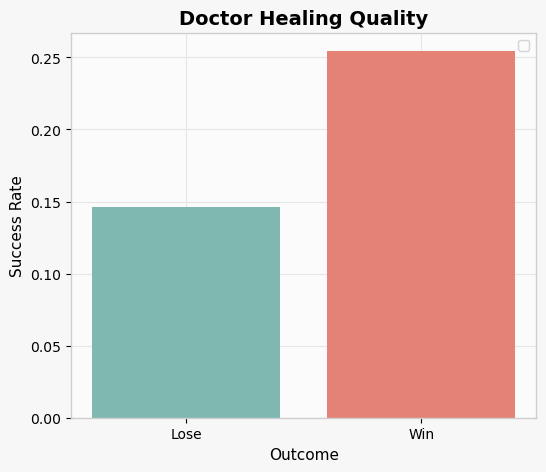

In [100]:
fig, ax = plt.subplots(figsize=(6,5))

ax.bar(
    ["Lose","Win"],
    doctor_quality_analysis["avg_success_rate"],
    color=[OUTCOME_COLORS["Lose"], OUTCOME_COLORS["Win"]],
)

ax.set_xlabel("Outcome")
ax.set_ylabel("Success Rate")
ax.set_title("Doctor Healing Quality")
ax.legend()

plt.show()

C:\Users\宋润琳\AppData\Local\Temp\ipykernel_27272\1935155658.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


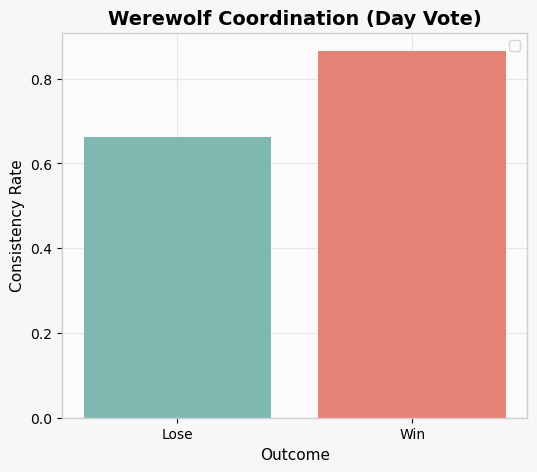

In [102]:
fig, ax = plt.subplots(figsize=(6,5))

ax.bar(
    ["Lose","Win"],
    wolf_analysis["avg_consistency"],
    color=[OUTCOME_COLORS["Lose"], OUTCOME_COLORS["Win"]]
)

ax.set_xlabel("Outcome")
ax.set_ylabel("Consistency Rate")
ax.legend()

ax.set_title("Werewolf Coordination (Day Vote)")

plt.show()

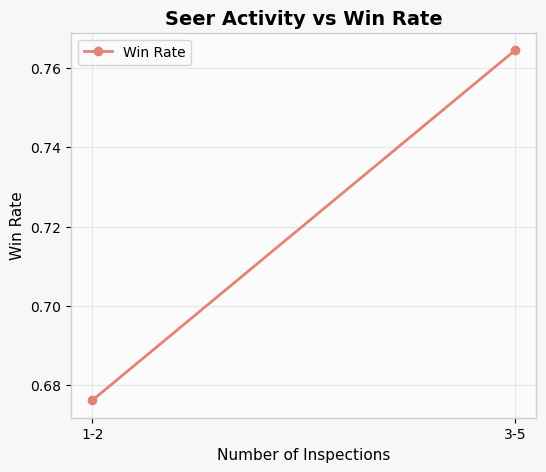

In [93]:
fig, ax = plt.subplots(figsize=(6,5))

ax.plot(
    seer_bin_analysis["seer_bin"].astype(str),
    seer_bin_analysis["win_rate"],
    marker="o",
    color="#e48375",
    linewidth=2,
    label="Win Rate"
)

ax.set_xlabel("Number of Inspections")
ax.set_ylabel("Win Rate")
ax.legend()

ax.set_title("Seer Activity vs Win Rate")

plt.show()

C:\Users\宋润琳\AppData\Local\Temp\ipykernel_27272\1549295532.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


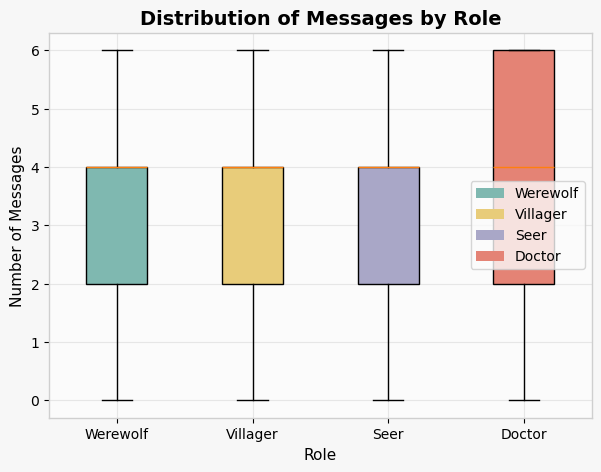

In [95]:
fig, ax = plt.subplots(figsize=(7,5))

roles = ["Werewolf","Villager","Seer","Doctor"]
data = [msg_by_role[msg_by_role["role"]==r]["n_messages"] for r in roles]

bp = ax.boxplot(
    data,
    labels=roles,
    patch_artist=True,
    widths=0.45,
    showfliers=False
)

for patch, r in zip(bp["boxes"], roles):
    patch.set_facecolor(ROLE_COLORS[r])

# 手动加 legend（boxplot默认没有）
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=ROLE_COLORS[r], label=r) for r in roles]

ax.set_xlabel("Role")
ax.set_ylabel("Number of Messages")
ax.legend(handles=legend_elements)

ax.set_title("Distribution of Messages by Role")

plt.show()